In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print('All libraries imported successfully')
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

All libraries imported successfully
Pandas version: 2.1.4
Numpy version: 1.23.5
Matplotlib version: 3.8.4
Seaborn version: 0.13.2


# Dataset 1: Customer Support Tickets

In [2]:
# Load Data
tickets = pd.read_csv('/Users/vishalhooda/Downloads/customer_support_tickets.csv')

print('=' * 70)
print('DATASET: CUSTOMER SUPPORT TICKETS')
print('=' * 70)

print(f"\nShape: {tickets.shape[0]:,} rows * {tickets.shape[1]} columns")

# Display first few rows
print('\nFirst 5 Rows:')
tickets.head()

DATASET: CUSTOMER SUPPORT TICKETS

Shape: 8,469 rows * 17 columns

First 5 Rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.000
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.000
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.000


In [3]:
# Column Information
print('=' * 70)
print('COLUMN INFORMATION')
print('=' * 70 + '\n')

# Display all column names
print('All Columns:')
for i, col in enumerate(tickets.columns, 1):
    print(f'{i:2d}. {col}')

# Display data types
print('\nDATA TYPES:')
print(tickets.dtypes)

# Detailed info
print('\nDETAILED INFO:')
tickets.info()

COLUMN INFORMATION

All Columns:
 1. Ticket ID
 2. Customer Name
 3. Customer Email
 4. Customer Age
 5. Customer Gender
 6. Product Purchased
 7. Date of Purchase
 8. Ticket Type
 9. Ticket Subject
10. Ticket Description
11. Ticket Status
12. Resolution
13. Ticket Priority
14. Ticket Channel
15. First Response Time
16. Time to Resolution
17. Customer Satisfaction Rating

DATA TYPES:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resol

In [4]:
# Basic Statistics
print('=' * 70)
print('STATISTICAL SUMMARY')
print('=' * 70)

# Numerical columns
numerical_cols = tickets.select_dtypes(include = [np.number]).columns
if len(numerical_cols) > 0:
    print('NUMERICAL COLUMNS:')
    print(tickets[numerical_cols].describe().T)
    print()

# Categorical columns
categorical_cols = tickets.select_dtypes(include = ['object']).columns
print(f'\nCATEGORICAL COLUMNS: {len(categorical_cols)}')
for col in categorical_cols:
    print(f'{col}: {tickets[col].nunique():,} unique values')

STATISTICAL SUMMARY
NUMERICAL COLUMNS:
                                count     mean      std    min      25%  \
Ticket ID                    8469.000 4235.000 2444.934  1.000 2118.000   
Customer Age                 8469.000   44.027   15.296 18.000   31.000   
Customer Satisfaction Rating 2769.000    2.991    1.407  1.000    2.000   

                                  50%      75%      max  
Ticket ID                    4235.000 6352.000 8469.000  
Customer Age                   44.000   57.000   70.000  
Customer Satisfaction Rating    3.000    4.000    5.000  


CATEGORICAL COLUMNS: 14
Customer Name: 8,028 unique values
Customer Email: 8,320 unique values
Customer Gender: 3 unique values
Product Purchased: 42 unique values
Date of Purchase: 730 unique values
Ticket Type: 5 unique values
Ticket Subject: 16 unique values
Ticket Description: 8,077 unique values
Ticket Status: 3 unique values
Resolution: 2,769 unique values
Ticket Priority: 4 unique values
Ticket Channel: 4 unique val

MISSING VALUES ANALYSIS
                      Column  Missing Count  Missing Percentage
Customer Satisfaction Rating           5700              67.304
          Time to Resolution           5700              67.304
                  Resolution           5700              67.304
         First Response Time           2819              33.286


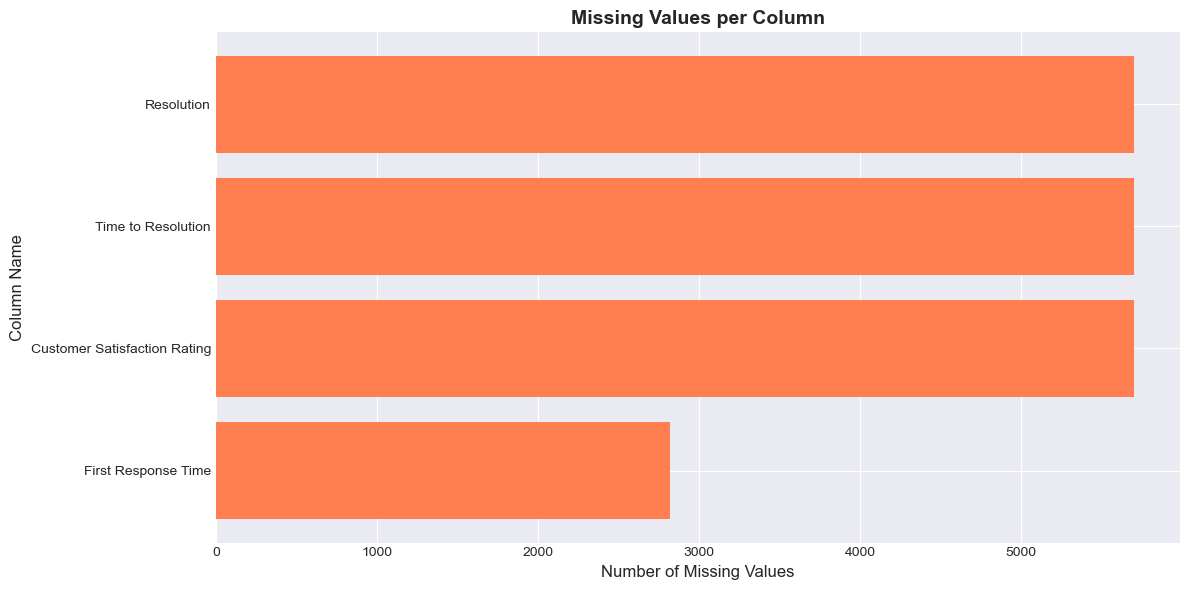

In [5]:
# Missing Values Analysis
print('=' * 70)
print('MISSING VALUES ANALYSIS')
print('=' * 70)

# Calculate missing values
missing_counts = tickets.isnull().sum()
missing_percent = (missing_counts / len(tickets)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing Percentage': missing_percent.values
}).sort_values('Missing Count', ascending = False)

# Display only columns with missing values
missing_with_nulls = missing_df[missing_df['Missing Count'] > 0]
if len(missing_with_nulls) > 0:
    print(missing_with_nulls.to_string(index = False))
else:
    print('No missing values found')

# Visualize missing values
plt.figure(figsize = (12, 6))
missing_with_nulls_sorted = missing_with_nulls.sort_values('Missing Count', ascending = True)
plt.barh(missing_with_nulls_sorted['Column'], missing_with_nulls_sorted['Missing Count'], color = 'coral')
plt.xlabel('Number of Missing Values', fontsize = 12)
plt.ylabel('Column Name', fontsize = 12)
plt.title('Missing Values per Column', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [6]:
# Duplicate Records
print('=' * 70)
print('DUPLICATE RECORDS')
print('=' * 70)

duplicates = tickets.duplicated().sum()
print(f"Total duplicate rows: {duplicates:,} ({(duplicates / len(tickets) * 100):.2f}%)")

# Check duplicates in Ticket ID
if 'Ticket ID' in tickets.columns:
    duplicate_ids = tickets['Ticket ID'].duplicated().sum()
    print(f'Duplicate Ticket IDs: {duplicate_ids}')

DUPLICATE RECORDS
Total duplicate rows: 0 (0.00%)
Duplicate Ticket IDs: 0


CUSTOMER DEMOGRAPHICS
AGE STATISTICS:
count   8469.000
mean      44.027
std       15.296
min       18.000
25%       31.000
50%       44.000
75%       57.000
max       70.000
Name: Customer Age, dtype: float64

GENDER DISTRIBUTION
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

Male: 34.2%
Female: 34.1%
Other: 31.7%


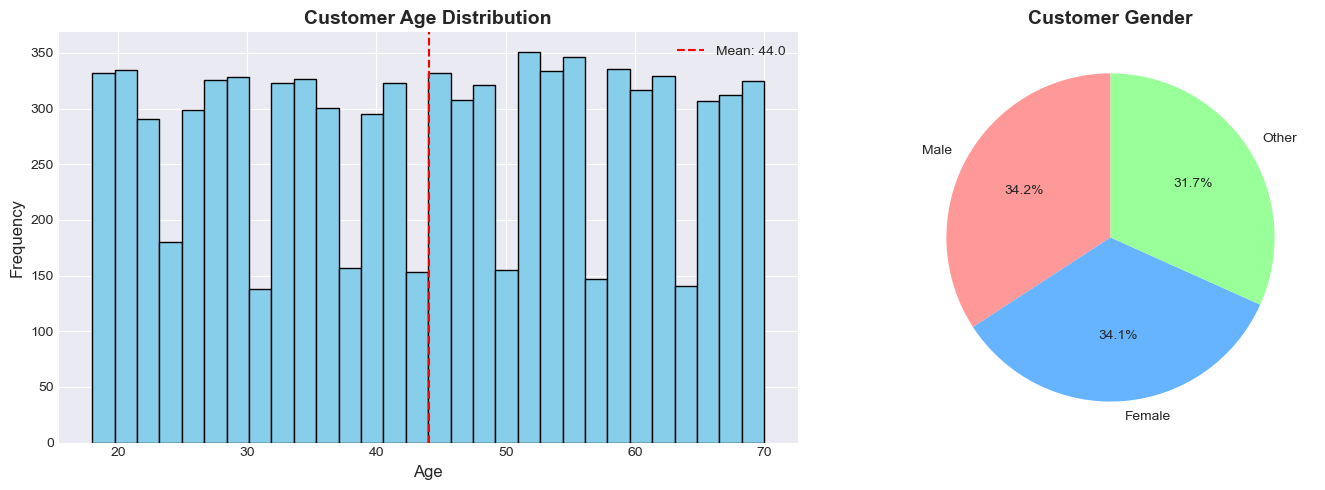

In [7]:
# Customer Demographics
print('=' * 70)
print('CUSTOMER DEMOGRAPHICS')
print('=' * 70)

# Age statistics
if 'Customer Age' in tickets.columns:
    print('AGE STATISTICS:')
    print(tickets['Customer Age'].describe())
    print()

# Gender distribution
if 'Customer Gender' in tickets.columns:
    print('GENDER DISTRIBUTION')
    gender_counts = tickets['Customer Gender'].value_counts()
    print(gender_counts)
    print()

    # Gender percentages
    for gender, count in gender_counts.items():
        pct = (count / len(tickets)) * 100
        print(f'{gender}: {pct:.1f}%')

# Visualize demographics
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Age distribution
if 'Customer Age' in tickets.columns:
    axes[0].hist(tickets['Customer Age'].dropna(), bins = 30, color = 'skyblue', edgecolor = 'black')
    axes[0].set_xlabel('Age', fontsize = 12)
    axes[0].set_ylabel('Frequency', fontsize = 12)
    axes[0].set_title('Customer Age Distribution', fontsize = 14, fontweight = 'bold')
    axes[0].axvline(tickets['Customer Age'].mean(), color = 'red', linestyle = '--', label = f"Mean: {tickets['Customer Age'].mean():.1f}")
    axes[0].legend()

# Gender distribution
if 'Customer Gender' in tickets.columns:
    gender_counts = tickets['Customer Gender'].value_counts()
    axes[1].pie(gender_counts, labels = gender_counts.index, autopct = '%1.1f%%', startangle = 90,
                colors = ['#ff9999', '#66b3ff', '#99ff99'])
    axes[1].set_title('Customer Gender', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

TICKET TYPE ANALYSIS
TICKET TYPES:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Refund request: 20.7%
Technical issue: 20.6%
Cancellation request: 20.0%
Product inquiry: 19.4%
Billing inquiry: 19.3%


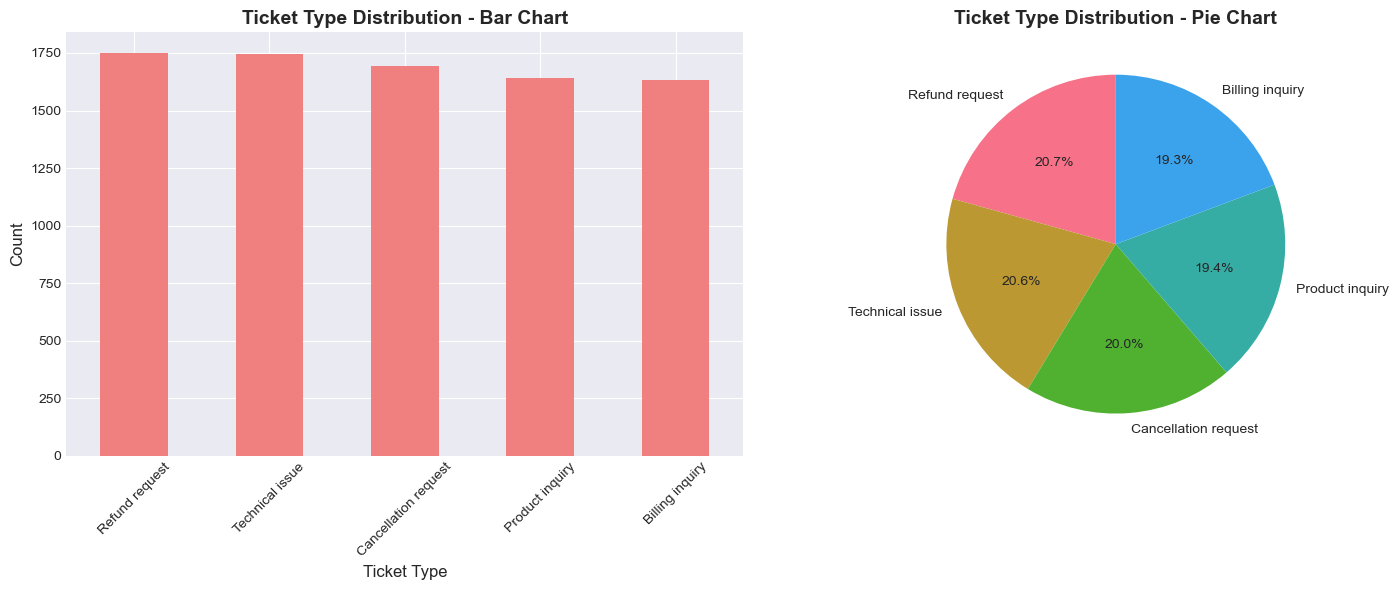

In [8]:
# Ticket Type Analysis
print('=' * 70)
print('TICKET TYPE ANALYSIS')
print('=' * 70)

if 'Ticket Type' in tickets.columns:
    print('TICKET TYPES:')
    ticket_types = tickets['Ticket Type'].value_counts()
    print(ticket_types)
    print()

    # Percentages
    for ticket_type, count in ticket_types.items():
        pct = (count / len(tickets)) * 100
        print(f"{ticket_type}: {pct:.1f}%")

    # Visulization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 6))

    # Bar chart
    ticket_types.plot(kind = 'bar', ax = ax1, color = 'lightcoral')
    ax1.set_title('Ticket Type Distribution - Bar Chart', fontsize = 14, fontweight = 'bold')
    ax1.set_xlabel('Ticket Type', fontsize = 12)
    ax1.set_ylabel('Count', fontsize = 12)
    ax1.tick_params(axis = 'x', rotation = 45)

    # Pie chart
    ax2.pie(ticket_types, labels = ticket_types.index, autopct = '%1.1f%%', startangle = 90)
    ax2.set_title('Ticket Type Distribution - Pie Chart', fontsize = 14, fontweight = 'bold')

    plt.tight_layout()
    plt.show()

TICKET SUBJECT ANALYSIS
TOP 10 TICKET SUBJECTS:
Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Battery life             542
Network problem          539
Installation support     530
Product setup            529
Payment issue            526
Name: count, dtype: int64



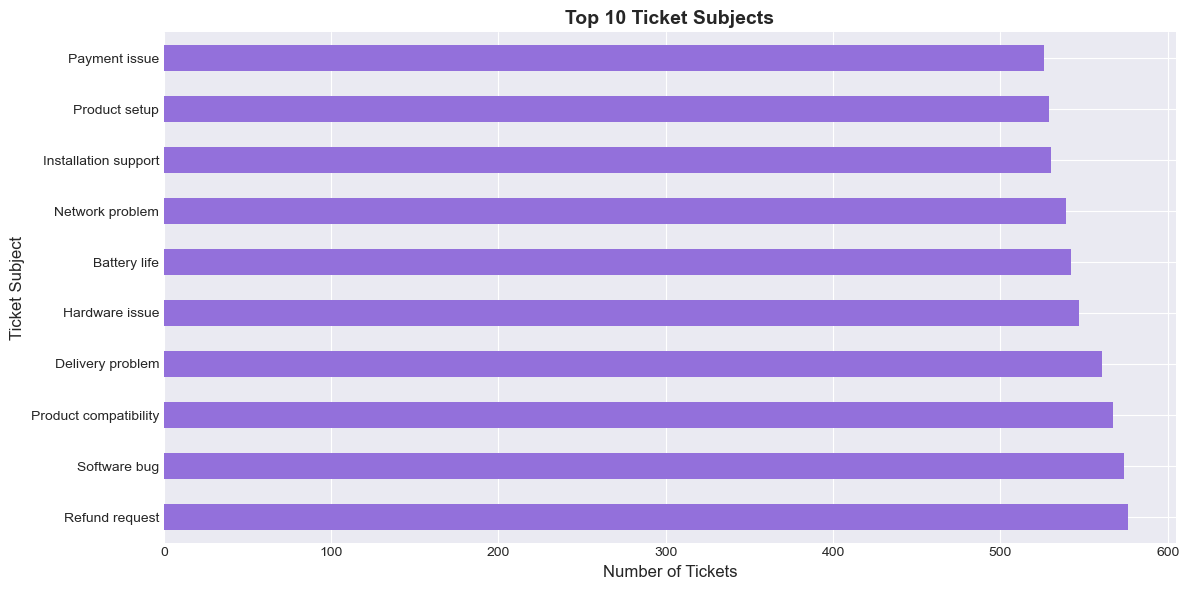

In [9]:
# Ticket Subject Analysis
print('=' * 70)
print('TICKET SUBJECT ANALYSIS')
print('=' * 70)

if 'Ticket Subject' in tickets.columns:
    print('TOP 10 TICKET SUBJECTS:')
    subject_counts = tickets['Ticket Subject'].value_counts().head(10)
    print(subject_counts)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    subject_counts.plot(kind = 'barh', color = 'mediumpurple')
    plt.xlabel('Number of Tickets', fontsize = 12)
    plt.ylabel('Ticket Subject', fontsize = 12)
    plt.title('Top 10 Ticket Subjects', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

TICKET PRIORITY ANALYSIS
TICKETS PRIORITY LEVELS:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Medium : 25.9%
Critical : 25.1%
High : 24.6%
Low : 24.4%


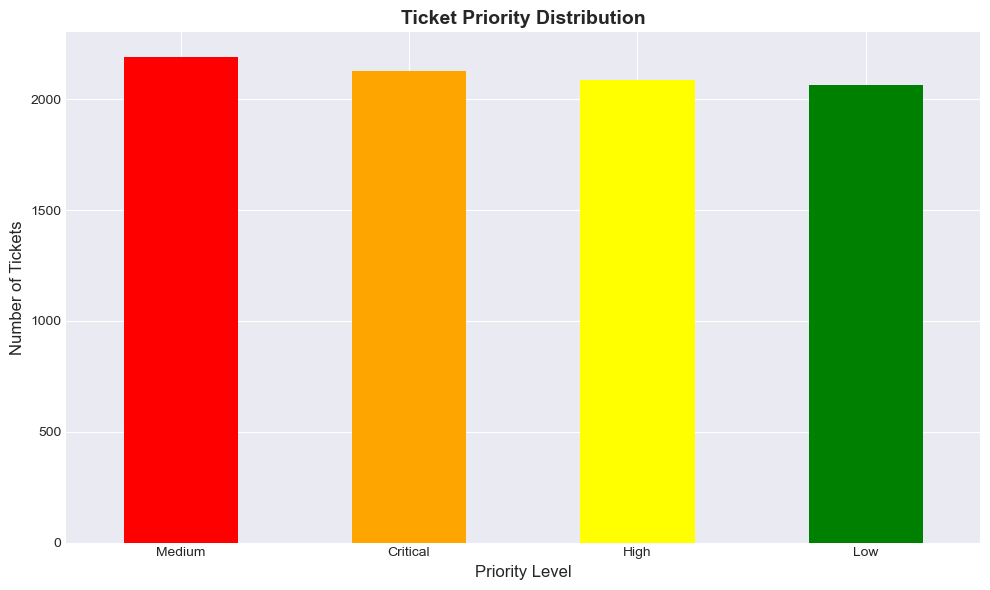

In [10]:
# Ticket Priority Analysis
print('=' * 70)
print('TICKET PRIORITY ANALYSIS')
print('=' * 70)

if 'Ticket Priority' in tickets.columns:
    print('TICKETS PRIORITY LEVELS:')
    priority_counts = tickets['Ticket Priority'].value_counts()
    print(priority_counts)
    print()

    # Percentages
    for priority, count in priority_counts.items():
        pct = (count / len(tickets)) * 100
        print(f"{priority} : {pct:.1f}%")

    # Visualization
    plt.figure(figsize = (10, 6))
    priority_counts.plot(kind = 'bar', color = ['red', 'orange', 'yellow', 'green'])
    plt.title('Ticket Priority Distribution', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Priority Level', fontsize = 12)
    plt.ylabel('Number of Tickets', fontsize = 12)
    plt.xticks(rotation = 0)
    plt.tight_layout()
    plt.show()

TICKET CHANNEL ANALYSIS
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Email: 25.3%
Phone: 25.2%
Social media: 25.0%
Chat: 24.5%


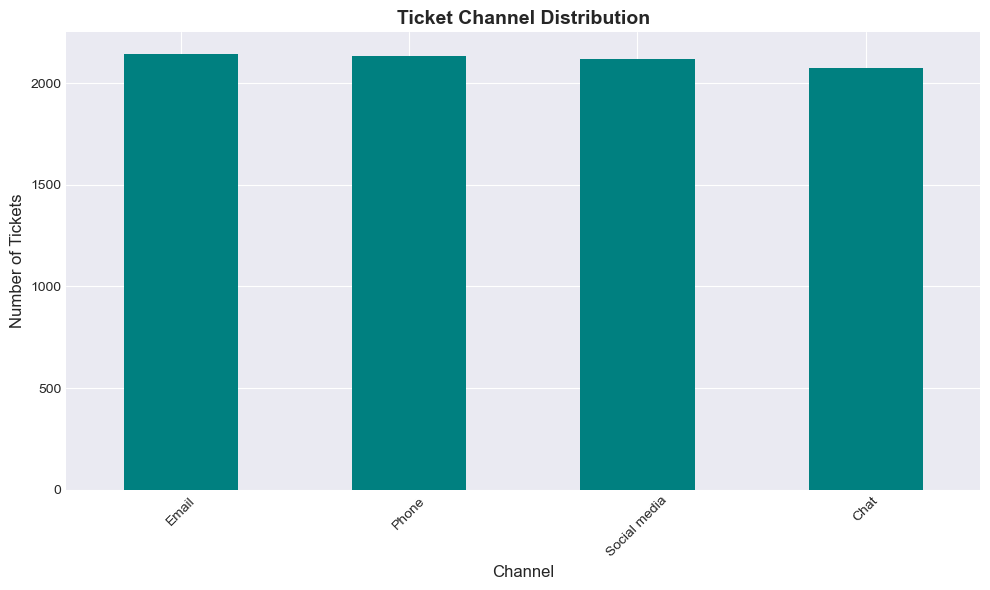

In [11]:
# Ticket Channel Analysis
print('=' * 70)
print('TICKET CHANNEL ANALYSIS')
print('=' * 70)

if 'Ticket Channel' in tickets.columns:
    channel_counts = tickets['Ticket Channel'].value_counts()
    print(channel_counts)
    print()

    # Percentages
    for channel, count in channel_counts.items():
        pct = (count / len(tickets)) * 100
        print(f"{channel}: {pct:.1f}%")

    # Visualization
    plt.figure(figsize = (10, 6))
    channel_counts.plot(kind = 'bar', color = 'teal')
    plt.title('Ticket Channel Distribution', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Channel', fontsize = 12)
    plt.ylabel('Number of Tickets', fontsize = 12)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()